##1. Comprendre les types de classification

Il existe plusieurs types de classification en Machine Learning.

La classification binaire consiste à classer les données en deux catégories seulement. Par exemple, prédire si un client va quitter une banque ou non : 0 = le client reste, 1 = le client quitte.

La classification multiclasse consiste à classer les données dans plusieurs catégories, mais chaque exemple appartient à une seule classe. Par exemple, reconnaître un chiffre manuscrit entre 0 et 9 avec le dataset MNIST.

La classification multi-étiquettes consiste à attribuer plusieurs classes à un même exemple. Par exemple, une image peut contenir à la fois une voiture, une personne et un chien. Dans ce cas, une seule image peut avoir plusieurs étiquettes en même temps.

In [1]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

print("Version TensorFlow :", tf.__version__)

Version TensorFlow : 2.20.0


In [2]:


samples = 1000

X, y = make_circles(
    n_samples=samples,
    noise=0.03,
    random_state=42
)

print("X : ")
print(X)

print("\ny : ")
print(y)

print("\nDimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

X : 
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 ...
 [-0.13690036 -0.81001183]
 [ 0.67036156 -0.76750154]
 [ 0.28105665  0.96382443]]

y : 
[1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 0 1 1 0 1 0 0 1 0 0 0 1 1 1 0 0 1 0 0 0 1
 1 1 0 0 0 0 1 0 0 1 1 0 1 1 1 0 1 0 0 1 0 0 1 0 0 1 0 1 1 1 1 0 1 0 0 1 1
 0 0 1 0 1 0 1 0 0 0 0 1 1 1 1 0 0 0 1 0 1 0 1 0 0 1 1 0 1 0 1 1 1 1 0 1 1
 1 1 1 0 0 0 1 1 0 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1 0 0 0 0 0 0 0 1 0 1 1 1 0
 1 0 1 0 1 0 1 0 0 1 0 1 1 1 1 1 1 1 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 1 1
 0 0 0 1 1 1 1 1 0 0 0 0 0 1 0 0 1 1 1 1 1 0 1 0 1 0 0 1 1 1 0 1 0 1 1 0 1
 1 0 1 0 1 0 1 1 0 1 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1
 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 0 1 0 0 0 1 1 1 1 0 0 0
 1 0 0 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 0 0 0 0 1 0 0 0 0 1 1 1 0 0 1 0 1 0 1
 1 0 0 1 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1
 0 1 0 0 0 1 0 0 1 1 0 0 1 0 0 1 1 0 1 1 0 0 1 0 1 0 0 0 1 1 0 0 1 1 1 

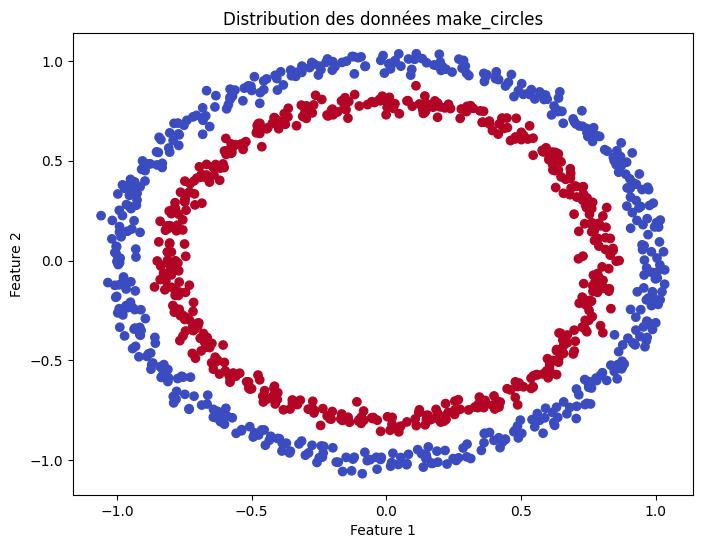

In [3]:


plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="coolwarm"
)

plt.title("Distribution des données make_circles")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Le dataset contient deux classes disposées sous forme de cercles. Une classe forme le cercle intérieur et l’autre classe forme le cercle extérieur. Cette distribution montre que les données ne sont pas séparables avec une simple droite. Il faut donc un modèle capable d’apprendre une frontière de décision non linéaire.

In [4]:


tf.random.set_seed(42)

model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

model_1.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["accuracy"]
)

history_1 = model_1.fit(
    X,
    y,
    epochs=100,
    verbose=0
)

loss_1, accuracy_1 = model_1.evaluate(X, y)

print("Loss du modèle 1 :", loss_1)
print("Accuracy du modèle 1 :", accuracy_1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4730 - loss: 0.6933
Loss du modèle 1 : 0.6932879686355591
Accuracy du modèle 1 : 0.4729999899864197


##CONCLUSION

Le premier modèle est très simple, car il contient seulement une couche Dense avec un neurone. Ce type de modèle peut apprendre une séparation simple, mais il a du mal avec des données circulaires. Comme les points sont organisés en cercles, une frontière linéaire ne suffit pas pour bien séparer les classes.

In [5]:


def plot_decision_boundary(model, X, y):
    """
    Cette fonction affiche la frontière de décision du modèle.
    Elle permet de voir comment le modèle sépare les deux classes.
    """

    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 100),
        np.linspace(y_min, y_max, 100)
    )

    grid_points = np.c_[xx.ravel(), yy.ravel()]

    y_pred = model.predict(grid_points, verbose=0)

    if y_pred.shape[-1] > 1:
        y_pred = np.argmax(y_pred, axis=1)
    else:
        y_pred = np.round(y_pred).reshape(xx.shape)

    plt.figure(figsize=(8, 6))

    plt.contourf(
        xx,
        yy,
        y_pred,
        cmap="coolwarm",
        alpha=0.4
    )

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap="coolwarm"
    )

    plt.title("Frontière de décision")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

In [6]:


tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

model_2.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

history_2 = model_2.fit(
    X,
    y,
    epochs=100,
    verbose=0
)

loss_2, accuracy_2 = model_2.evaluate(X, y)

print("Loss du modèle 2 :", loss_2)
print("Accuracy du modèle 2 :", accuracy_2)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4880 - loss: 0.6933
Loss du modèle 2 : 0.693331778049469
Accuracy du modèle 2 : 0.4880000054836273


In [7]:


tf.random.set_seed(42)

model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model_3.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"]
)

history_3 = model_3.fit(
    X,
    y,
    epochs=100,
    verbose=0
)

loss_3, accuracy_3 = model_3.evaluate(X, y)

print("Loss du modèle 3 :", loss_3)
print("Accuracy du modèle 3 :", accuracy_3)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0026
Loss du modèle 3 : 0.0026249317452311516
Accuracy du modèle 3 : 1.0


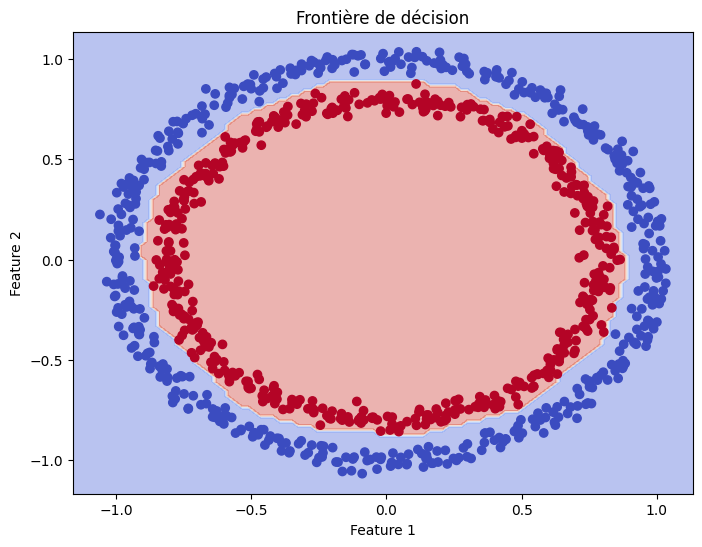

In [8]:
plot_decision_boundary(model_3, X, y)

Le troisième modèle utilise ReLU dans les couches cachées et Sigmoid dans la couche de sortie. ReLU permet au réseau neuronal d’apprendre des relations non linéaires. Sigmoid transforme la sortie finale en probabilité entre 0 et 1. Ce modèle est donc beaucoup plus adapté à la classification binaire avec des données circulaires.

In [9]:


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test :", X_test.shape)
print("Dimensions de y_train :", y_train.shape)
print("Dimensions de y_test :", y_test.shape)

Dimensions de X_train : (800, 2)
Dimensions de X_test : (200, 2)
Dimensions de y_train : (800,)
Dimensions de y_test : (200,)


In [10]:


tf.random.set_seed(42)

final_model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

final_model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"]
)

history_final = final_model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    verbose=0
)

train_loss, train_accuracy = final_model.evaluate(X_train, y_train)
test_loss, test_accuracy = final_model.evaluate(X_test, y_test)

print("Loss sur train :", train_loss)
print("Accuracy sur train :", train_accuracy)

print("\nLoss sur test :", test_loss)
print("Accuracy sur test :", test_accuracy)

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 4.8300e-04 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0049 
Loss sur train : 0.0004830041143577546
Accuracy sur train : 1.0

Loss sur test : 0.004947809502482414
Accuracy sur test : 1.0


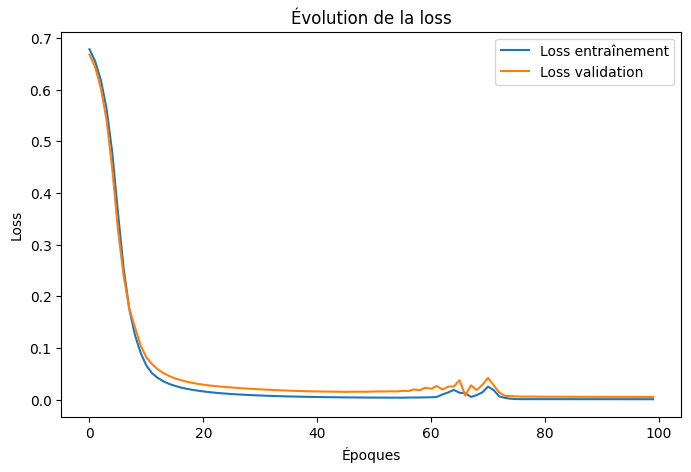

In [11]:


plt.figure(figsize=(8, 5))

plt.plot(history_final.history["loss"], label="Loss entraînement")
plt.plot(history_final.history["val_loss"], label="Loss validation")

plt.title("Évolution de la loss")
plt.xlabel("Époques")
plt.ylabel("Loss")
plt.legend()
plt.show()

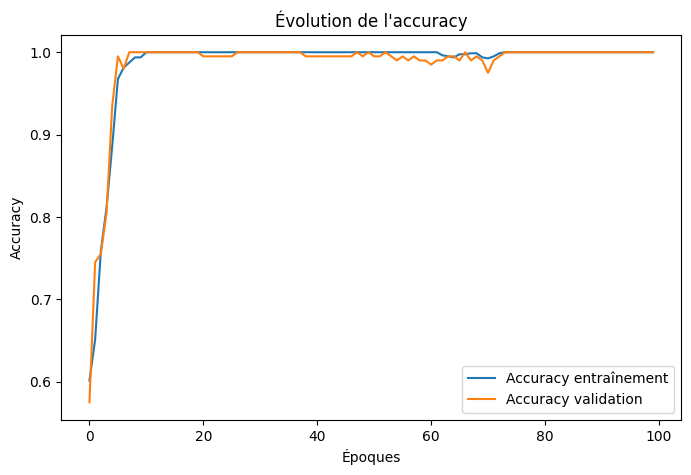

In [12]:


plt.figure(figsize=(8, 5))

plt.plot(history_final.history["accuracy"], label="Accuracy entraînement")
plt.plot(history_final.history["val_accuracy"], label="Accuracy validation")

plt.title("Évolution de l'accuracy")
plt.xlabel("Époques")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

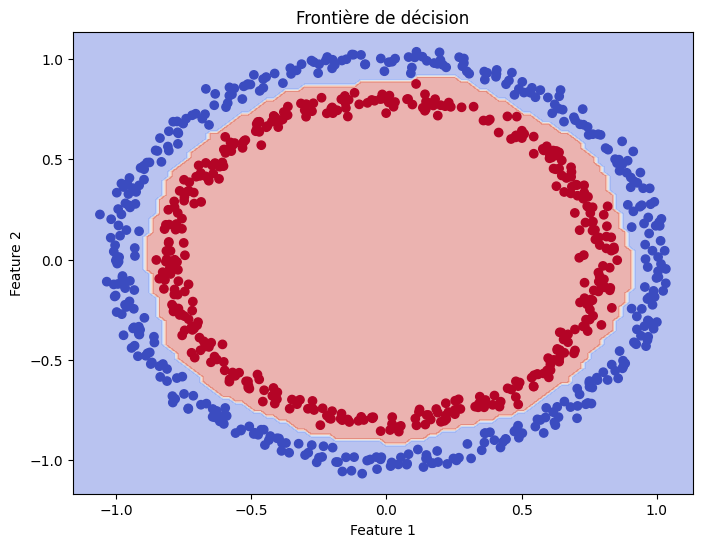

In [13]:


plot_decision_boundary(final_model, X_train, y_train)

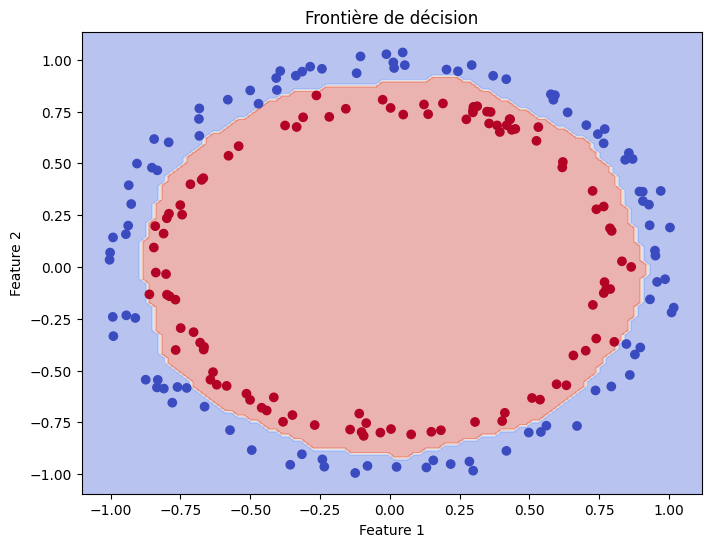

In [14]:


plot_decision_boundary(final_model, X_test, y_test)

In [15]:


y_pred_prob = final_model.predict(X_test)
y_pred = np.round(y_pred_prob).astype(int).reshape(-1)

print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))

print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Matrice de confusion :
[[100   0]
 [  0 100]]

Rapport de classification :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [16]:


models_results = pd.DataFrame({
    "Model": ["Model 1 - Simple", "Model 2 - Adam", "Model 3 - ReLU + Sigmoid"],
    "Loss": [loss_1, loss_2, loss_3],
    "Accuracy": [accuracy_1, accuracy_2, accuracy_3]
})

display(models_results)

,Model,Loss,Accuracy
0,Model 1 - Simple,0.693288,0.473
1,Model 2 - Adam,0.693332,0.488
2,Model 3 - ReLU + Sigmoid,0.002625,1.000


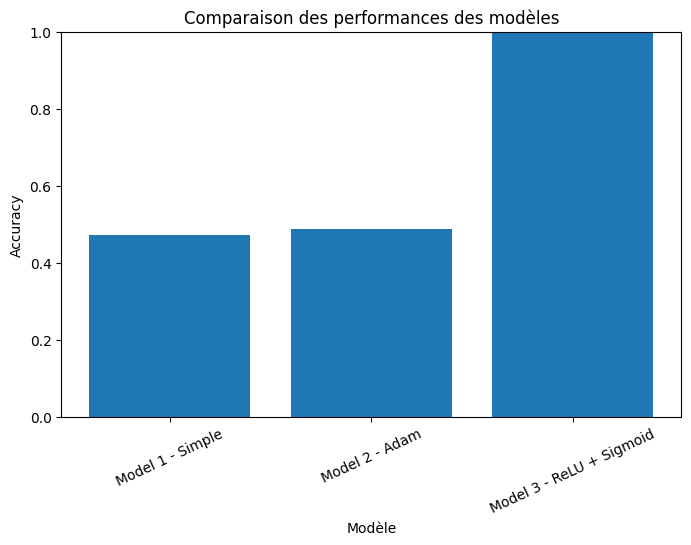

In [17]:


plt.figure(figsize=(8, 5))

plt.bar(
    models_results["Model"],
    models_results["Accuracy"]
)

plt.title("Comparaison des performances des modèles")
plt.xlabel("Modèle")
plt.ylabel("Accuracy")
plt.xticks(rotation=25)
plt.ylim(0, 1)

plt.show()

##RESUMER

Dans cet exercice, nous avons étudié un problème de classification binaire avec un dataset généré par make_circles. Les données sont organisées sous forme de deux cercles, ce qui signifie qu’elles ne sont pas séparables par une simple droite.

Nous avons d’abord construit un modèle de base avec une seule couche Dense. Ce modèle était trop simple pour apprendre correctement la forme circulaire des données. Ensuite, nous avons amélioré le modèle en ajoutant plus de couches, plus de neurones et l’optimiseur Adam.

L’ajout des fonctions d’activation ReLU dans les couches cachées et Sigmoid dans la couche de sortie a permis au réseau neuronal d’apprendre une frontière de décision non linéaire. Nous avons ensuite divisé les données en ensemble d’entraînement et ensemble de test afin d’évaluer la capacité du modèle à généraliser.

La visualisation de la frontière de décision nous a permis de voir comment le modèle sépare les deux classes. Cet exercice montre que la visualisation des données, le choix des fonctions d’activation, l’optimiseur, le nombre de couches, le nombre de neurones et le nombre d’époques sont des éléments très importants pour améliorer les performances d’un modèle de classification.